In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("programmer3/power-quality-fault-detection-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Abhishek\.cache\kagglehub\datasets\programmer3\power-quality-fault-detection-dataset\versions\1


In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('power_quality_fault_dataset.csv')

In [4]:
df.head()

,ID,Fault_Type,Phase,RMS_Voltage,Peak_Voltage,THD,Duration_ms,DWT_Energy_Level1,DWT_Energy_Level2,DWT_Entropy,Signal_Noise_Ratio_dB,Label
0,1,Transient,C,224.44,406.38,5.42,159,15.08,37.49,4.75,20.02,3
1,2,Transient,B,235.05,388.57,3.61,262,48.88,18.11,3.45,22.79,3
2,3,Transient,A,231.11,384.64,5.21,140,87.39,35.61,2.80,20.27,3
3,4,Normal,C,229.83,325.02,1.70,273,13.09,45.92,2.04,33.25,0
4,5,Sag,B,147.08,208.01,1.62,200,85.81,25.24,2.58,38.53,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2367 entries, 0 to 2366
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     2367 non-null   int64  
 1   Fault_Type             2367 non-null   object 
 2   Phase                  2367 non-null   object 
 3   RMS_Voltage            2367 non-null   float64
 4   Peak_Voltage           2367 non-null   float64
 5   THD                    2367 non-null   float64
 6   Duration_ms            2367 non-null   int64  
 7   DWT_Energy_Level1      2367 non-null   float64
 8   DWT_Energy_Level2      2367 non-null   float64
 9   DWT_Entropy            2367 non-null   float64
 10  Signal_Noise_Ratio_dB  2367 non-null   float64
 11  Label                  2367 non-null   int64  
dtypes: float64(7), int64(3), object(2)
memory usage: 222.0+ KB


In [6]:
df['Fault_Type'].value_counts()

Fault_Type
Normal       492
Harmonics    485
Transient    473
Sag          467
Swell        450
Name: count, dtype: int64

<Axes: xlabel='Fault_Type', ylabel='count'>

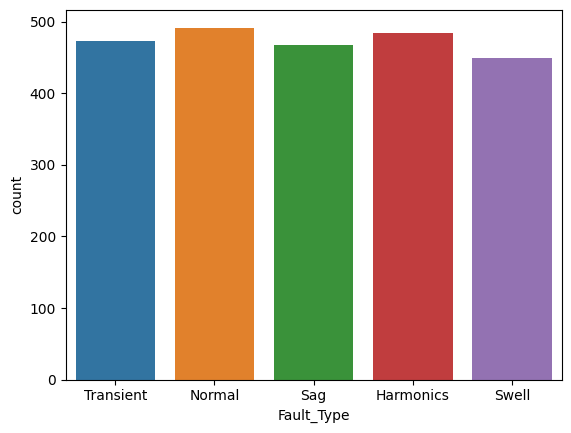

In [7]:
sns.countplot(data=df, x='Fault_Type', hue='Fault_Type')

In [8]:
df['Phase'].unique()

array(['C', 'B', 'A'], dtype=object)

In [9]:
df['Phase'] = df['Phase'].astype('category')

In [10]:
df['Phase'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 2367 entries, 0 to 2366
Series name: Phase
Non-Null Count  Dtype   
--------------  -----   
2367 non-null   category
dtypes: category(1)
memory usage: 2.6 KB


In [11]:
df['Phase']=df['Phase'].cat.codes

In [12]:
df.head()

,ID,Fault_Type,Phase,RMS_Voltage,Peak_Voltage,THD,Duration_ms,DWT_Energy_Level1,DWT_Energy_Level2,DWT_Entropy,Signal_Noise_Ratio_dB,Label
0,1,Transient,2,224.44,406.38,5.42,159,15.08,37.49,4.75,20.02,3
1,2,Transient,1,235.05,388.57,3.61,262,48.88,18.11,3.45,22.79,3
2,3,Transient,0,231.11,384.64,5.21,140,87.39,35.61,2.80,20.27,3
3,4,Normal,2,229.83,325.02,1.70,273,13.09,45.92,2.04,33.25,0
4,5,Sag,1,147.08,208.01,1.62,200,85.81,25.24,2.58,38.53,1


In [13]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
ID,2367.0,1184.000000,683.438366,1.00,592.500,1184.00,1775.500,2367.00
Phase,2367.0,0.966624,0.816245,0.00,0.000,1.00,2.000,2.00
RMS_Voltage,2367.0,221.905327,39.640015,113.99,223.625,230.14,236.885,300.93
Peak_Voltage,2367.0,328.814812,66.782209,161.21,317.650,329.77,383.450,465.68
THD,2367.0,4.742281,3.329978,-0.25,2.400,3.61,5.805,18.94
Duration_ms,2367.0,153.099704,82.788425,10.00,83.000,153.00,224.000,299.00
DWT_Energy_Level1,2367.0,54.344854,25.867413,10.00,32.860,54.15,75.845,99.95
DWT_Energy_Level2,2367.0,27.491128,12.941691,5.01,16.365,28.20,38.430,49.99
DWT_Entropy,2367.0,3.026595,1.160081,1.00,2.010,3.02,4.040,5.00
Signal_Noise_Ratio_dB,2367.0,30.001132,5.700109,20.01,25.070,30.05,34.805,39.99


In [14]:
df.shape

(2367, 12)

In [15]:
df.columns

Index(['ID', 'Fault_Type', 'Phase', 'RMS_Voltage', 'Peak_Voltage', 'THD',
       'Duration_ms', 'DWT_Energy_Level1', 'DWT_Energy_Level2', 'DWT_Entropy',
       'Signal_Noise_Ratio_dB', 'Label'],
      dtype='object')

In [16]:
feature= ['Phase', 'RMS_Voltage', 'Peak_Voltage', 'THD',
       'Duration_ms', 'DWT_Energy_Level1', 'DWT_Energy_Level2', 'DWT_Entropy',
       'Signal_Noise_Ratio_dB']
label=['Label']

array([[<Axes: title={'center': 'ID'}>,
        <Axes: title={'center': 'Phase'}>,
        <Axes: title={'center': 'RMS_Voltage'}>],
       [<Axes: title={'center': 'Peak_Voltage'}>,
        <Axes: title={'center': 'THD'}>,
        <Axes: title={'center': 'Duration_ms'}>],
       [<Axes: title={'center': 'DWT_Energy_Level1'}>,
        <Axes: title={'center': 'DWT_Energy_Level2'}>,
        <Axes: title={'center': 'DWT_Entropy'}>],
       [<Axes: title={'center': 'Signal_Noise_Ratio_dB'}>,
        <Axes: title={'center': 'Label'}>, <Axes: >]], dtype=object)

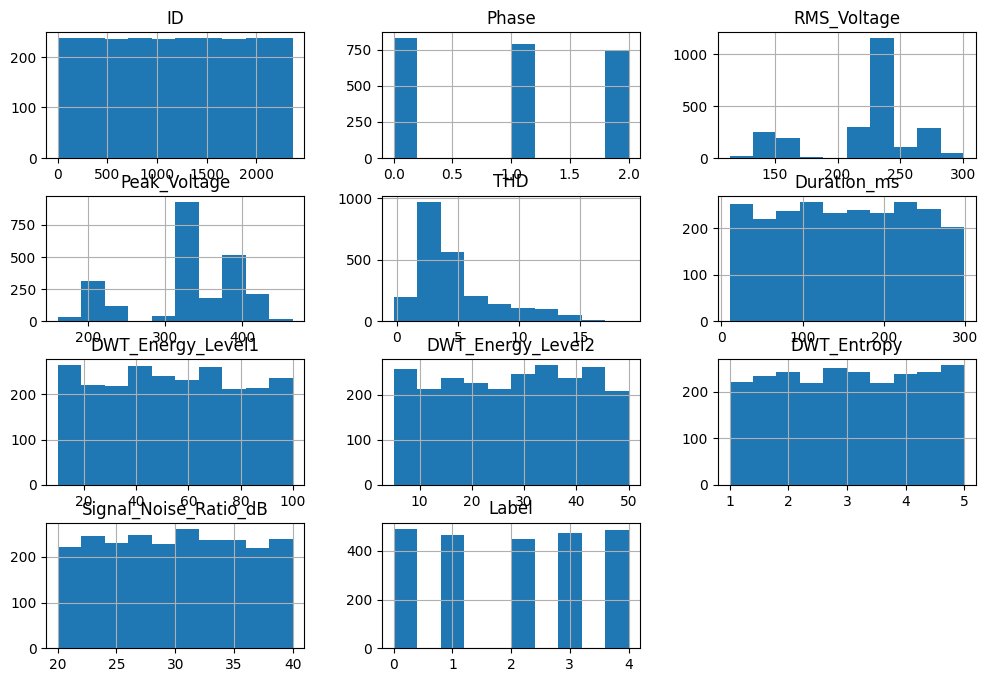

In [17]:
df.hist(figsize=(12,8))

<Axes: >

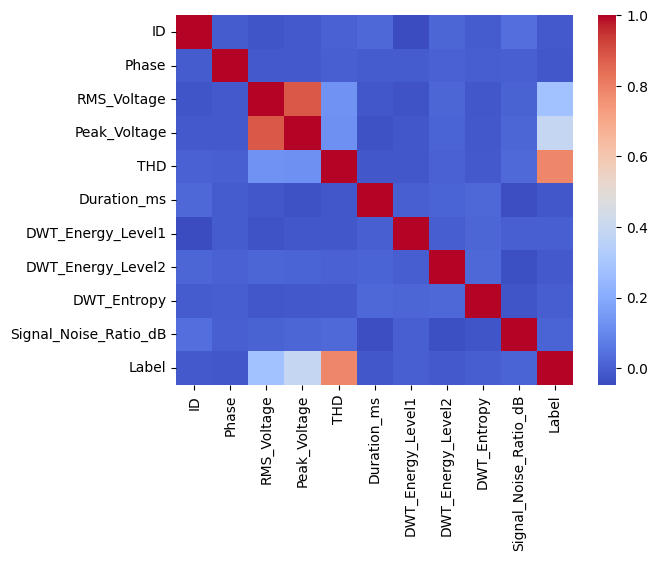

In [18]:
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm")

In [19]:
from sklearn.preprocessing import StandardScaler

In [20]:
scaler = StandardScaler()

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
xtr,xts,ytr,yts = train_test_split(df[feature], df[label], test_size=0.2, shuffle=True)

In [23]:
xtr.shape

(1893, 9)

In [24]:
ytr.shape

(1893, 1)

In [25]:
xtr.head()

,Phase,RMS_Voltage,Peak_Voltage,THD,Duration_ms,DWT_Energy_Level1,DWT_Energy_Level2,DWT_Entropy,Signal_Noise_Ratio_dB
1170,1,223.86,395.81,7.65,236,69.60,10.23,3.22,25.74
2279,1,233.89,390.40,2.58,58,46.50,20.05,2.38,35.21
1306,2,231.13,326.87,10.77,201,81.38,29.59,2.69,32.37
1671,1,231.35,327.17,13.63,72,38.57,12.00,1.30,34.77
21,0,287.89,407.13,2.31,77,31.35,19.64,3.99,32.99


In [26]:
xtr=scaler.fit_transform(xtr)
xts=scaler.transform(xts)

In [27]:
xtr = torch.FloatTensor(xtr)
xts = torch.FloatTensor(xts)

In [28]:
ytr = torch.LongTensor(ytr.values)

In [29]:
yts = torch.LongTensor(yts.values)

In [30]:
ytr.shape

torch.Size([1893, 1])

In [31]:
ytr

tensor([[3],
        [3],
        [4],
        ...,
        [4],
        [4],
        [1]])

In [32]:
xtr.shape

torch.Size([1893, 9])

In [33]:
from torch.utils.data import TensorDataset, DataLoader

In [34]:
train_data = TensorDataset(xtr,ytr)

In [35]:
test_data = TensorDataset(xts,yts)

In [36]:
train_loader = DataLoader(train_data,batch_size=64,shuffle =True)
test_loader = DataLoader(test_data,batch_size=32,shuffle =True)

In [37]:
train_loader

In [38]:
from sklearn.metrics import accuracy_score

In [39]:
class mlpmodel(nn.Module):
    def __init__(self, layer_1_neurons):
        super().__init__()

        self.fc1 = nn.Linear(in_features=9, out_features=layer_1_neurons)
        self.fc2 = nn.Linear(in_features=layer_1_neurons, out_features=5)

    def forward(self,x):
        x = F.relu(self.fc1(x))
        x = F.log_softmax(self.fc2(x),dim=-1)

        return x

In [40]:
model = mlpmodel(layer_1_neurons=16)

In [41]:
model

mlpmodel(
  (fc1): Linear(in_features=9, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=5, bias=True)
)

In [42]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [43]:
epochs = 200

In [44]:
torch.cuda.is_available()

True

In [45]:
model.cuda()

mlpmodel(
  (fc1): Linear(in_features=9, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=5, bias=True)
)

In [46]:
train_loss = []
test_loss = []
train_acc = []
test_acc = []

for epoch in range(epochs):
    model.train()

    for x,y in train_loader:
        x=x.cuda()
        y=y.cuda()

        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred,y.view(-1))
        loss.backward()
        optimizer.step()
        y = y.view(-1).cpu().detach()
        pred = np.argmax(pred.cpu().detach(),axis=-1)
    train_loss.append(loss.cpu().detach().item())
    train_acc.append(accuracy_score(y,pred))
    

    model.eval()
    with torch.no_grad():
        for x,y in test_loader:
            x=x.cuda()
            y=y.cuda()

            pred = model(x)
            loss = criterion(pred,y.view(-1))
            y = y.view(-1).cpu().detach()
            pred = np.argmax(pred.cpu().detach(),axis=-1)
        test_loss.append(loss.cpu().detach().item())
        test_acc.append(accuracy_score(y,pred))

        print(f"EPOCH:{epoch}, train loss {train_loss[-1]:.4f}, train acc {train_acc[-1]:.4f}, test loss {test_loss[-1]:.4f}, test acc {test_acc[-1]:.4f}")

EPOCH:0, train loss 1.5662, train acc 0.2703, test loss 1.5966, test acc 0.1923
EPOCH:1, train loss 1.4933, train acc 0.4324, test loss 1.4874, test acc 0.2308
EPOCH:2, train loss 1.4434, train acc 0.4865, test loss 1.4117, test acc 0.5385
EPOCH:3, train loss 1.1157, train acc 0.8378, test loss 1.2461, test acc 0.6923
EPOCH:4, train loss 1.1241, train acc 0.6216, test loss 1.1799, test acc 0.6538
EPOCH:5, train loss 0.9115, train acc 0.8108, test loss 1.0587, test acc 0.8077
EPOCH:6, train loss 0.8158, train acc 0.8649, test loss 0.8018, test acc 0.8846
EPOCH:7, train loss 0.7974, train acc 0.8649, test loss 1.0446, test acc 0.6538
EPOCH:8, train loss 0.7128, train acc 0.8108, test loss 0.6914, test acc 0.9615
EPOCH:9, train loss 0.7242, train acc 0.9730, test loss 0.7045, test acc 0.9231
EPOCH:10, train loss 0.4755, train acc 0.9730, test loss 0.5061, test acc 0.9231
EPOCH:11, train loss 0.4596, train acc 0.8919, test loss 0.4622, test acc 0.9615
EPOCH:12, train loss 0.4170, train acc

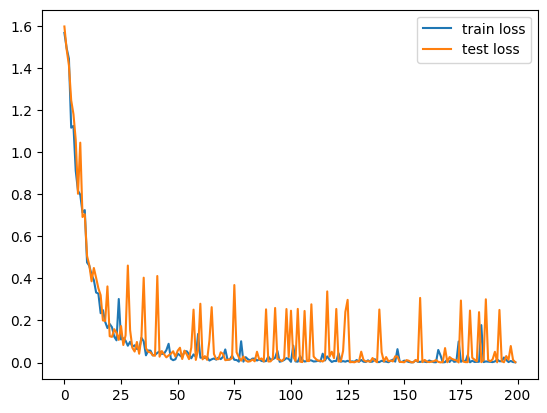

In [47]:
plt.plot(range(epochs), train_loss, label='train loss')
plt.plot(range(epochs), test_loss, label='test loss')
plt.legend()
plt.show()

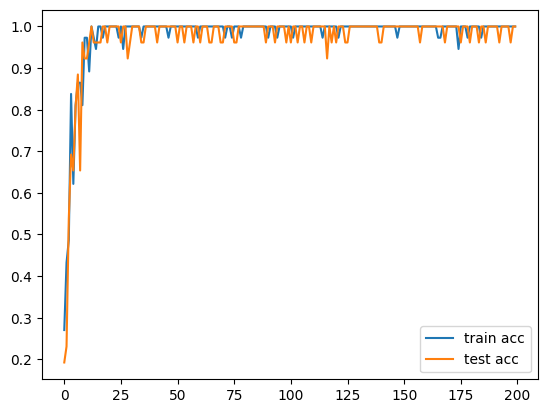

In [48]:
plt.plot(range(epochs), train_acc, label='train acc')
plt.plot(range(epochs), test_acc, label='test acc')
plt.legend()
plt.show()

In [49]:
xts.shape

torch.Size([474, 9])

In [50]:
final_loader = DataLoader(test_data,batch_size=474,shuffle =True)

In [51]:
with torch.no_grad():
    for x,y in final_loader:
        x=x.cuda()
        y=y.cuda()
        pred = model(x)
        loss = criterion(pred, y.view(-1))

In [52]:
y_eval = np.array(np.argmax(pred.cpu().detach(), axis=-1))

C:\Users\Abhishek\AppData\Local\Temp\ipykernel_29788\959432330.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_eval = np.array(np.argmax(pred.cpu().detach(), axis=-1))


In [53]:
y_true = np.array(y.view(-1).cpu().detach())

C:\Users\Abhishek\AppData\Local\Temp\ipykernel_29788\2082786003.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_true = np.array(y.view(-1).cpu().detach())


In [54]:
from sklearn.metrics import classification_report, confusion_matrix

In [55]:
accuracy_score(y_true,y_eval)

0.9915611814345991

<Axes: >

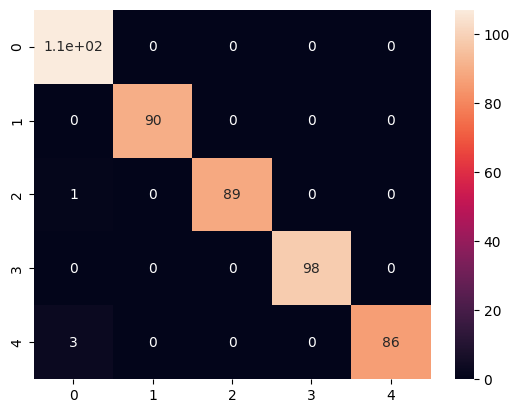

In [56]:
sns.heatmap(confusion_matrix(y_true,y_eval), annot=True)

In [57]:
print(classification_report(y_true,y_eval))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       107
           1       1.00      1.00      1.00        90
           2       1.00      0.99      0.99        90
           3       1.00      1.00      1.00        98
           4       1.00      0.97      0.98        89

    accuracy                           0.99       474
   macro avg       0.99      0.99      0.99       474
weighted avg       0.99      0.99      0.99       474

